# Tucker Surrogate Evaluation

Tucker rank grid $r_s \in \{4, 8\}$ (frequency mode, $K \to r_s$) $\times\ r_z \in \{8, 16, 32\}$ (latent mode,
$d_z \to r_z$), for SLAE-Tucker and LLAE-Tucker. All checkpoints share the same phase-1 AE
($d_z = 64$, $K = 16$, $\gamma = 0.01$).

Three metrics per simulation:

| | definition | depends on |
|---|---|---|
| $\varepsilon_{\mathrm{field}}$ | relative $L^2$ error on $U(t)$ | full pipeline |
| $\varepsilon_{\mathrm{trunc}}$ | $\|\hat{Z} - \Pi\hat{Z}\| / \|\hat{Z}\|$, $\Pi$ the Tucker projector | factors only |
| $\varepsilon_{\mathrm{reg}}$ | $\|\hat{\mathcal{G}}_{\mathrm{pred}} - \hat{\mathcal{G}}_{\mathrm{true}}\| / \|\hat{\mathcal{G}}_{\mathrm{true}}\|$ | surrogate MLP only |

The last two split the difficulty — compression or MLP? — in the latent space, where they are decoder-free.
A physical-space oracle would not be a valid lower bound (Section 4).

In [1]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import gc
import glob
import re
import functools

import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline import InferencePipeline
from laplace_surrogate.models.encoder_decoder import ConvEncoder
from laplace_surrogate.models import tucker

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device, torch.cuda.get_device_name(0) if device == 'cuda' else '')

Device: cuda NVIDIA RTX A5000


/users/eleves-b/2023/keyvan.attarian/diffusion_ae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset loading

In [2]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '../checkpoints'
CACHE_DIR  = 'cache_tucker'
N          = 128
BATCH_SIZE = 16

R_S_GRID   = (4, 8)       # Tucker frequency-mode ranks under study

os.makedirs(CACHE_DIR, exist_ok=True)

U_raw = np.load(DATA_PATH, mmap_mode='r')
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} simulations, Nt={Nt_full}, {H}x{W}')

doe = np.load(DOE_PATH)
theta_np = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)

split    = np.load(SPLIT_PATH)
test_idx = split['test_idx'].tolist()
print(f'Test set: {len(test_idx)} simulations')

Dataset: 8100 simulations, Nt=150, 128x128
Test set: 1620 simulations


In [3]:
def load_u(idx: int) -> np.ndarray:
    """Load U and resize to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u


def load_u_batch(idx_list) -> np.ndarray:
    return np.stack([load_u(i) for i in idx_list])

## 2. Checkpoints

Epoch and best `val/l2rel` are read from the `ModelCheckpoint` callback state.

In [4]:
_TUCK_PAT = re.compile(
    r'^(?P<cls>\w+?)__(?P<ae_stem>.+?)__t(?P<n_trunk>\d+)h(?P<n_head>\d+)'
    r'_rs(?P<r_s>\d+)rz(?P<r_z>\d+)$'
)

PALETTE = {'SLAETuckerModel': 'steelblue', 'LLAETuckerModel': 'tomato'}
FAMILY  = {'SLAETuckerModel': 'SLAE-Tucker', 'LLAETuckerModel': 'LLAE-Tucker'}


def _best_val_l2rel(ckpt: dict):
    """Best val/l2rel, stored in the ModelCheckpoint callback state."""
    for v in ckpt.get('callbacks', {}).values():
        if isinstance(v, dict) and v.get('best_model_score') is not None:
            return float(v['best_model_score'])
    return float('nan')


meta = {}
for path in sorted(glob.glob(os.path.join(CKPT_DIR, '*TuckerModel__*_rs*rz*.ckpt'))):
    name = os.path.splitext(os.path.basename(path))[0]
    m    = _TUCK_PAT.match(name)
    if m is None or int(m.group('r_s')) not in R_S_GRID:
        continue
    ck    = torch.load(path, map_location='cpu', weights_only=False)
    state = ck['model_state']
    meta[name] = dict(
        path   = path,
        cls    = m.group('cls'),
        r_s    = int(m.group('r_s')),
        r_z    = int(m.group('r_z')),
        K      = ck['K'],
        d_z    = ck['latent_dim'],
        epoch  = ck['epoch'],
        step   = ck['global_step'],
        val    = _best_val_l2rel(ck),
        n_surr = sum(v.numel() for k, v in state.items() if k.startswith('surrogate')),
    )
    d = meta[name]
    d['ratio'] = d['r_s'] * d['r_z'] / (d['K'] * d['d_z'])
    del ck, state

_order  = lambda n: (meta[n]['cls'], meta[n]['r_s'], meta[n]['r_z'])
PLOTTED = sorted(meta, key=_order)

print(f'{len(meta)} Tucker checkpoints\n')
hdr = (f"{'checkpoint':<24} {'r_s':>4} {'r_z':>4} {'epoch':>6} {'step':>7} "
       f"{'best val/l2rel':>15} {'surr. params':>13}")
print(hdr); print('-' * len(hdr))
for n in PLOTTED:
    d   = meta[n]
    tag = f"{FAMILY[d['cls']]} rs{d['r_s']}rz{d['r_z']}"
    print(f"{tag:<24} {d['r_s']:>4} {d['r_z']:>4} {d['epoch']:>6} {d['step']:>7} "
          f"{d['val']:>15.4f} {d['n_surr']:>13,}")

print(f'\nGrid: r_s in {list(R_S_GRID)} x r_z in {sorted({d["r_z"] for d in meta.values()})}.')

12 Tucker checkpoints

checkpoint                r_s  r_z  epoch    step  best val/l2rel  surr. params
-------------------------------------------------------------------------------
LLAE-Tucker rs4rz8          4    8    289   93960          0.0819     1,350,212
LLAE-Tucker rs4rz16         4   16    295   95904          0.0660     1,366,660
LLAE-Tucker rs4rz32         4   32    295   95904          0.0542     1,399,556
LLAE-Tucker rs8rz8          8    8    299   97200          0.0807     1,906,312
LLAE-Tucker rs8rz16         8   16    298   96876          0.0618     1,939,208
LLAE-Tucker rs8rz32         8   32    286   92988          0.0522     2,005,000
SLAE-Tucker rs4rz8          4    8    297   96552          0.1339     1,341,988
SLAE-Tucker rs4rz16         4   16    290   94284          0.1196     1,350,212
SLAE-Tucker rs4rz32         4   32    297   96552          0.1149     1,366,660
SLAE-Tucker rs8rz8          8    8    295   95904          0.1366     1,889,864
SLAE-Tucker rs8rz

## 3. Evaluation

One pass over the test set per checkpoint computes all three metrics. The frozen encoder lives in the SLAE
surrogate checkpoint, but must be recovered from the phase-1 AE checkpoint for LLAE.

In [5]:
@functools.lru_cache(maxsize=4)
def load_ae_encoder(ae_path: str, N: int, latent_dim: int, cond_L: int):
    """Frozen encoder of the phase-1 LLAE (not stored in the surrogate checkpoint)."""
    ck  = torch.load(ae_path, map_location='cpu', weights_only=False)
    enc = ConvEncoder(in_channels=1, N=N, latent_dim=latent_dim, cond_L=cond_L)
    enc.load_state_dict({k[len('model.encoder.'):]: v
                         for k, v in ck['state_dict'].items() if k.startswith('model.encoder.')})
    return enc.eval()


def _relnorm(diff: torch.Tensor, ref: torch.Tensor) -> np.ndarray:
    """Per-sample ||diff_i|| / ||ref_i|| in %. Handles complex tensors."""
    num = diff.flatten(1).abs().norm(dim=1)
    den = ref.flatten(1).abs().norm(dim=1).clamp_min(1e-12)
    return (100.0 * num / den).cpu().numpy()


def _latents_and_core(model, ckpt, U_norm, theta_norm, enc):
    """Return (Z_hat_true, G_true, G_pred) for one batch."""
    if enc is None:                                    # SLAE: encoder is in the checkpoint
        zhat   = model._encode_targets(U_norm).float()
        G_pred = model.surrogate(theta_norm) * model.G_std + model.G_mean
    else:                                              # LLAE: encoder comes from the AE
        B, Nt, n, _ = U_norm.shape
        t = (torch.arange(Nt, dtype=U_norm.dtype, device=U_norm.device) / max(Nt - 1, 1)).repeat(B)
        z = enc(U_norm.reshape(B * Nt, 1, n, n), t).view(B, Nt, model.latent_dim)
        zhat = model.laplace.forward_transform(z.float())
        ri   = model.surrogate(theta_norm).view(B, model.r_s, model.r_z, 2)
        ri   = ri * model.G_hat_std + model.G_hat_mean
        G_pred = torch.complex(ri[..., 0], ri[..., 1])
    G_true = tucker.project(zhat, model.U_s, model.U_z)
    return zhat, G_true, G_pred


def eval_tucker(ckpt_path: str, idx_list, device='cpu', batch_size: int = BATCH_SIZE):
    """Per-simulation field L2rel (%), truncation error (%) and regression error (%)."""
    pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    m, ck = pipe.model, pipe.ckpt

    theta_mean = ck['theta_mean'].to(device).float()
    theta_std  = ck['theta_std'].to(device).float()

    enc = None
    if ck['model_type'] == 'LLAETuckerModel':
        ae_rel = ck['hyper_parameters']['cfg']['training']['ae_ckpt']
        enc = load_ae_encoder(os.path.join('..', ae_rel), ck['N'], ck['latent_dim'], ck['time_L'])
        enc = enc.to(device)

    l2rel, trunc, reg = [], [], []
    name = os.path.basename(ckpt_path)
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        bidx  = idx_list[start:start + batch_size]
        U_gt  = torch.from_numpy(load_u_batch(bidx)).to(device)
        theta = torch.from_numpy(theta_np[bidx]).to(device)
        tn    = (theta - theta_mean) / theta_std

        with torch.no_grad():
            U_pred = m.generate(tn)
            l2rel.extend(_relnorm(U_pred - U_gt, U_gt))

            U_norm = (U_gt - m.U_mean) / m.U_std
            zhat, G_true, G_pred = _latents_and_core(m, ck, U_norm, tn, enc)
            z_rec = tucker.reconstruct(G_true, m.U_s, m.U_z)
            trunc.extend(_relnorm(zhat - z_rec, zhat))
            reg.extend(_relnorm(G_pred - G_true, G_true))

        del U_gt, U_pred, U_norm, zhat, G_true, G_pred, z_rec
        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel), np.array(trunc), np.array(reg)

In [6]:
def _cache_path(name): return os.path.join(CACHE_DIR, f'{name}.npz')


def _cache_valid(name, ckpt_path):
    p = _cache_path(name)
    if not os.path.exists(p):
        return False
    try:
        d = np.load(p, allow_pickle=True)
        return (float(d['ckpt_mtime']) == os.path.getmtime(ckpt_path)
                and {'l2rel', 'trunc', 'reg'} <= set(d.files))
    except Exception as e:
        print(f'unreadable cache {p}: {e}')
        return False


results = {}
for name, d in meta.items():
    if _cache_valid(name, d['path']):
        c = np.load(_cache_path(name))
        results[name] = dict(l2rel=c['l2rel'], trunc=c['trunc'], reg=c['reg'])
        src = 'cache'
    else:
        l2, tr, rg = eval_tucker(d['path'], test_idx, device=device)
        np.savez(_cache_path(name), l2rel=l2, trunc=tr, reg=rg,
                 ckpt_mtime=np.float64(os.path.getmtime(d['path'])))
        results[name] = dict(l2rel=l2, trunc=tr, reg=rg)
        src = 'compute'
    r = results[name]
    print(f"[{src:>7}] {FAMILY[d['cls']]} rs{d['r_s']}rz{d['r_z']:<3} "
          f"field={np.median(r['l2rel']):6.2f}%  trunc={np.median(r['trunc']):6.2f}%  "
          f"reg={np.median(r['reg']):6.2f}%")

[  cache] LLAE-Tucker rs4rz16  field=  5.16%  trunc= 61.59%  reg=  3.83%
[  cache] LLAE-Tucker rs4rz32  field=  4.57%  trunc= 40.34%  reg=  5.67%
[  cache] LLAE-Tucker rs4rz8   field=  6.87%  trunc= 81.03%  reg=  3.80%
[  cache] LLAE-Tucker rs8rz16  field=  4.87%  trunc= 61.86%  reg=  4.38%
[  cache] LLAE-Tucker rs8rz32  field=  4.33%  trunc= 36.98%  reg=  7.25%
[  cache] LLAE-Tucker rs8rz8   field=  6.85%  trunc= 81.21%  reg=  4.99%
[  cache] SLAE-Tucker rs4rz16  field=  8.68%  trunc= 69.59%  reg=  5.18%
[  cache] SLAE-Tucker rs4rz32  field=  8.15%  trunc= 50.82%  reg=  6.58%
[  cache] SLAE-Tucker rs4rz8   field=  9.93%  trunc= 80.63%  reg=  5.70%
[  cache] SLAE-Tucker rs8rz16  field=  8.85%  trunc= 67.59%  reg=  5.83%
[  cache] SLAE-Tucker rs8rz32  field=  7.92%  trunc= 42.40%  reg=  6.76%
[  cache] SLAE-Tucker rs8rz8   field=  9.96%  trunc= 80.05%  reg=  7.16%


## 4. Diagnostic: decoder co-adaptation

The decoder is fine-tuned in phase 2 (`lr_decoder = 5e-5`). Decoding the *exact* core instead of the
*predicted* one should lower the error — if it raises it, the decoder has co-adapted to the predicted-core
distribution and a physical-space oracle is not a lower bound.

Computed on a `DIAG_N` subsample, so not comparable to the full-test medians of Section 11.

In [7]:
DIAG_N = 64   # subsample large enough for the effect to be unambiguous


def diagnose_coadaptation(ckpt_path, idx_list, device=device):
    pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    m, ck = pipe.model, pipe.ckpt
    tm = ck['theta_mean'].to(device).float(); ts = ck['theta_std'].to(device).float()
    is_llae = ck['model_type'] == 'LLAETuckerModel'
    enc = None
    if is_llae:
        ae_rel = ck['hyper_parameters']['cfg']['training']['ae_ckpt']
        enc = load_ae_encoder(os.path.join('..', ae_rel), ck['N'], ck['latent_dim'], ck['time_L']).to(device)

    e_pred, e_true = [], []
    for s in range(0, len(idx_list), BATCH_SIZE):
        bidx = idx_list[s:s + BATCH_SIZE]
        U_gt = torch.from_numpy(load_u_batch(bidx)).to(device)
        tn   = (torch.from_numpy(theta_np[bidx]).to(device) - tm) / ts
        with torch.no_grad():
            U_pred = m.generate(tn)
            _, G_true, _ = _latents_and_core(m, ck, (U_gt - m.U_mean) / m.U_std, tn, enc)
            z_rec = tucker.reconstruct(G_true, m.U_s, m.U_z)
            if is_llae:
                U_orc = m._decode_seq(m.laplace.inverse_transform(z_rec, m.Nt))
                U_orc = U_orc * m.U_std[None, None] + m.U_mean[None, None]
            else:
                U_orc = m._decode_z_k(z_rec.float())
            e_pred.extend(_relnorm(U_pred - U_gt, U_gt))
            e_true.extend(_relnorm(U_orc - U_gt, U_gt))
    pipe.model.cpu(); del pipe
    if device == 'cuda': torch.cuda.empty_cache()
    return np.array(e_pred), np.array(e_true)


probe = [n for n in PLOTTED if (meta[n]['r_s'], meta[n]['r_z']) == (8, 16)]
sub   = test_idx[:DIAG_N]

print(f"{'checkpoint':<24} {'predicted core':>15} {'exact core':>13} {'gap':>9}  co-adaptation")
print('-' * 82)
for n in probe:
    ep, et = diagnose_coadaptation(meta[n]['path'], sub)
    mp, mt = np.median(ep), np.median(et)
    gap    = mt - mp
    print(f"{FAMILY[meta[n]['cls']] + ' rs8rz16':<24} {mp:>14.2f}% {mt:>12.2f}% {gap:>+8.2f}pp  "
          f"{'strong' if gap > 1.0 else 'negligible'}")

checkpoint                predicted core    exact core       gap  co-adaptation
----------------------------------------------------------------------------------


LLAE-Tucker rs8rz16                8.84%         8.92%    +0.07pp  negligible


SLAE-Tucker rs8rz16               13.15%        24.27%   +11.11pp  strong


## 5. Median error over the $(r_s, r_z)$ grid

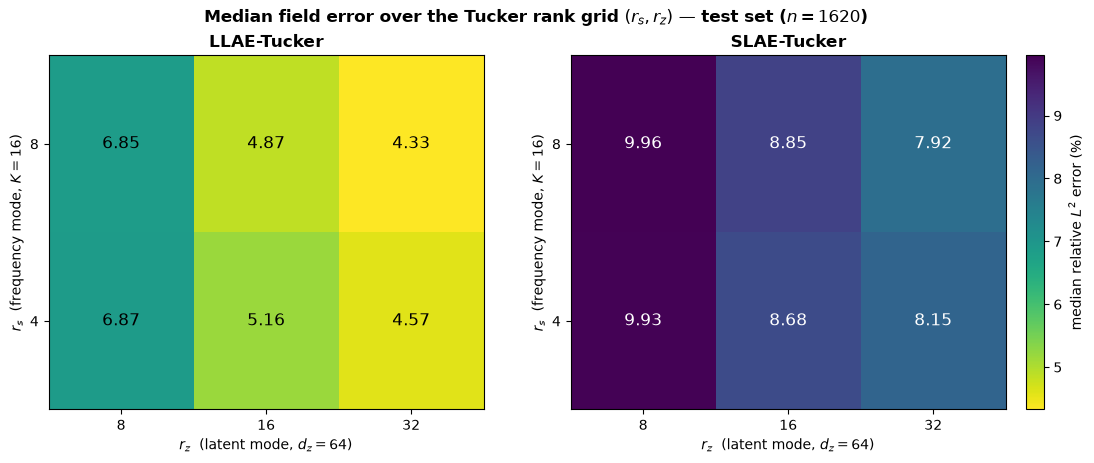

In [8]:
R_S  = list(R_S_GRID)
R_Z  = sorted({d['r_z'] for d in meta.values()})
CLSS = ['LLAETuckerModel', 'SLAETuckerModel']


def _lookup(cls, r_s, r_z):
    for n in PLOTTED:
        d = meta[n]
        if d['cls'] == cls and d['r_s'] == r_s and d['r_z'] == r_z:
            return n
    return None


def grid_matrix(cls, key, stat=np.median):
    M = np.full((len(R_S), len(R_Z)), np.nan)
    for i, rs in enumerate(R_S):
        for j, rz in enumerate(R_Z):
            n = _lookup(cls, rs, rz)
            if n is not None:
                M[i, j] = stat(results[n][key])
    return M


fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
vals = np.concatenate([grid_matrix(c, 'l2rel').ravel() for c in CLSS])
vmin, vmax = np.nanmin(vals), np.nanmax(vals)

for ax, cls in zip(axes, CLSS):
    M = grid_matrix(cls, 'l2rel')
    im = ax.imshow(M, cmap='viridis_r', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    for i in range(len(R_S)):
        for j in range(len(R_Z)):
            if not np.isnan(M[i, j]):
                ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=12,
                        color='white' if M[i, j] > (vmin + vmax) / 2 else 'black')
    ax.set_xticks(range(len(R_Z))); ax.set_xticklabels(R_Z)
    ax.set_yticks(range(len(R_S))); ax.set_yticklabels(R_S)
    ax.set_xlabel(r'$r_z$  (latent mode, $d_z = 64$)')
    ax.set_ylabel(r'$r_s$  (frequency mode, $K = 16$)')
    ax.set_title(FAMILY[cls], fontweight='bold')

fig.colorbar(im, ax=axes, label=r'median relative $L^2$ error (%)', fraction=0.03, pad=0.02)
fig.suptitle(r'Median field error over the Tucker rank grid $(r_s, r_z)$ — test set ($n = 1620$)',
             fontweight='bold')
plt.show()

## 6. Rank sweeps: $r_s$ and $r_z$ separately

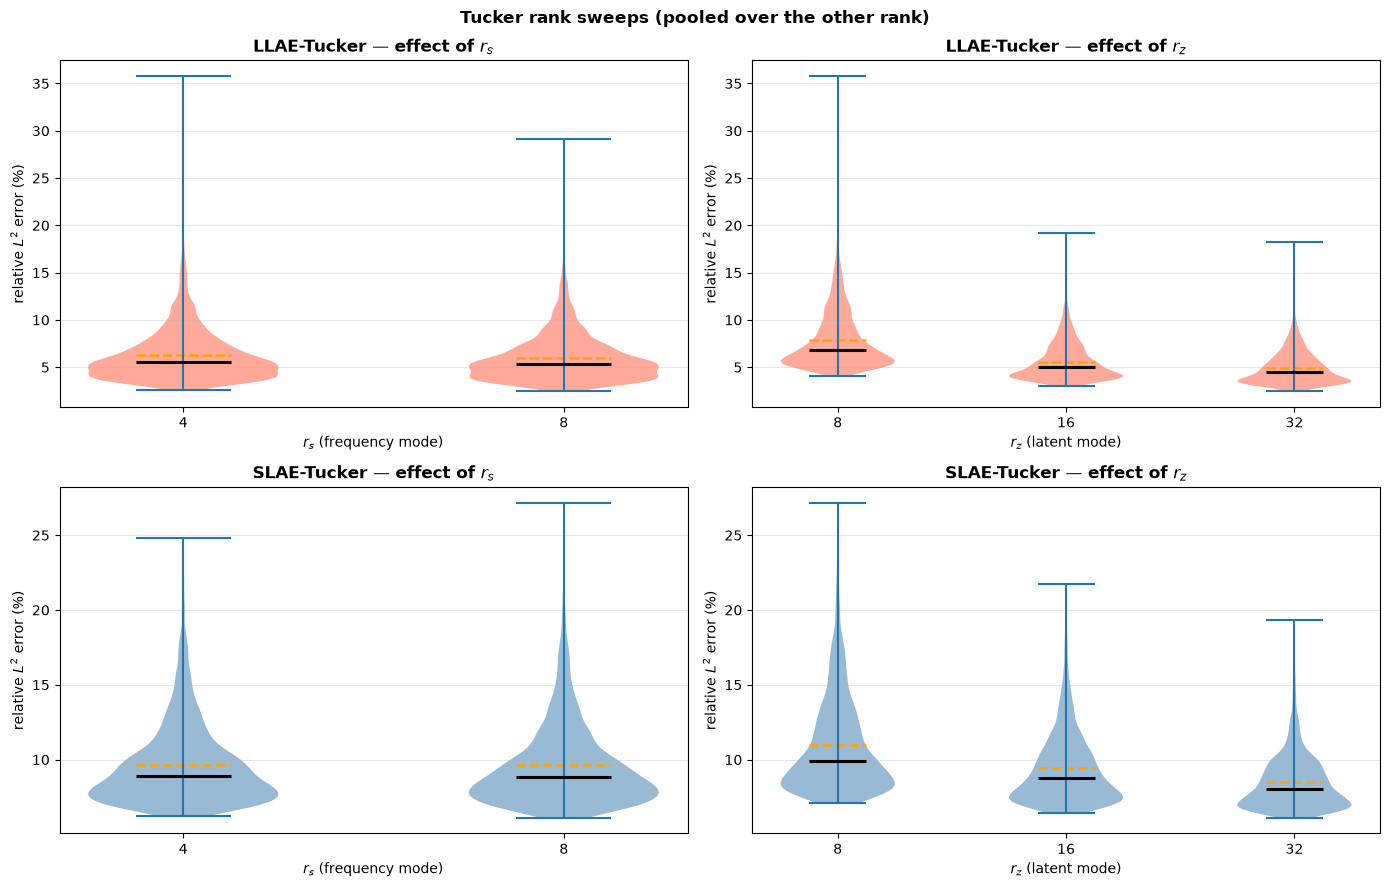

In [9]:
def _violin(ax, groups, title, xlabel, color):
    keys = sorted(groups)
    data = [groups[k] for k in keys]
    if not data:
        ax.set_title(f'{title}\n(no data)'); ax.axis('off'); return
    parts = ax.violinplot(data, showmedians=True, showmeans=True, showextrema=True)
    for b in parts['bodies']:
        b.set_facecolor(color); b.set_alpha(0.55)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');  parts['cmeans'].set_linestyle('--'); parts['cmeans'].set_linewidth(1.8)
    ax.set_xticks(range(1, len(keys) + 1)); ax.set_xticklabels(keys)
    ax.set_xlabel(xlabel); ax.set_ylabel(r'relative $L^2$ error (%)')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, cls in enumerate(CLSS):
    g_rs = {}
    for rs in R_S:
        pool = [results[_lookup(cls, rs, rz)]['l2rel'] for rz in R_Z if _lookup(cls, rs, rz)]
        if pool:
            g_rs[rs] = np.concatenate(pool)
    g_rz = {}
    for rz in R_Z:
        pool = [results[_lookup(cls, rs, rz)]['l2rel'] for rs in R_S if _lookup(cls, rs, rz)]
        if pool:
            g_rz[rz] = np.concatenate(pool)

    _violin(axes[row, 0], g_rs, f'{FAMILY[cls]} — effect of $r_s$', r'$r_s$ (frequency mode)', PALETTE[cls])
    _violin(axes[row, 1], g_rz, f'{FAMILY[cls]} — effect of $r_z$', r'$r_z$ (latent mode)', PALETTE[cls])

fig.suptitle('Tucker rank sweeps (pooled over the other rank)', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Error decomposition: truncation vs regression

Note that $\varepsilon_{\mathrm{trunc}}$ is a *latent* energy, not a field error: discarding 80 % of the latent
norm costs only ~7 % on $U(t)$, since the removed directions carry little decodable information. Its variation
with $(r_s, r_z)$ is what matters, hence the log scale.

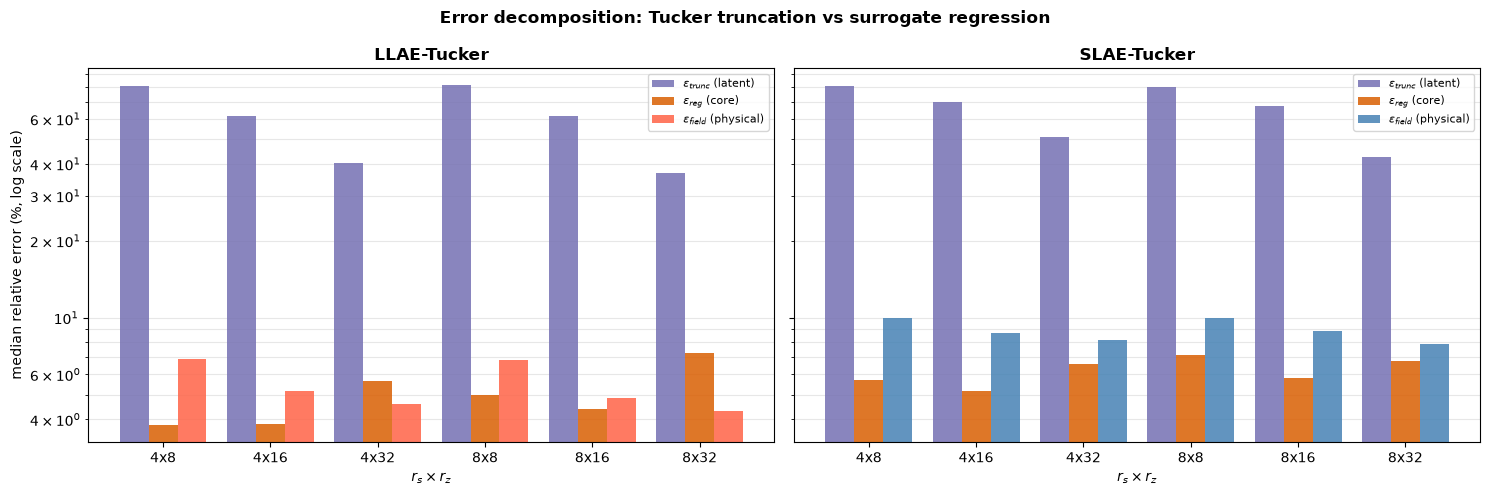

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, cls in zip(axes, CLSS):
    labels, tr, rg, fld = [], [], [], []
    for rs in R_S:
        for rz in R_Z:
            n = _lookup(cls, rs, rz)
            if n is None:
                continue
            labels.append(f'{rs}x{rz}')
            tr.append(np.median(results[n]['trunc']))
            rg.append(np.median(results[n]['reg']))
            fld.append(np.median(results[n]['l2rel']))
    x = np.arange(len(labels)); w = 0.27
    ax.bar(x - w, tr,  w, label=r'$\varepsilon_{trunc}$ (latent)',  color='#7570b3', alpha=0.85, zorder=2)
    ax.bar(x,     rg,  w, label=r'$\varepsilon_{reg}$ (core)',      color='#d95f02', alpha=0.85, zorder=2)
    ax.bar(x + w, fld, w, label=r'$\varepsilon_{field}$ (physical)', color=PALETTE[cls], alpha=0.85, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_xlabel(r'$r_s \times r_z$'); ax.set_title(FAMILY[cls], fontweight='bold')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both', zorder=0); ax.legend(fontsize=8)

axes[0].set_ylabel('median relative error (%, log scale)')
fig.suptitle('Error decomposition: Tucker truncation vs surrogate regression', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Error vs compression and vs surrogate size

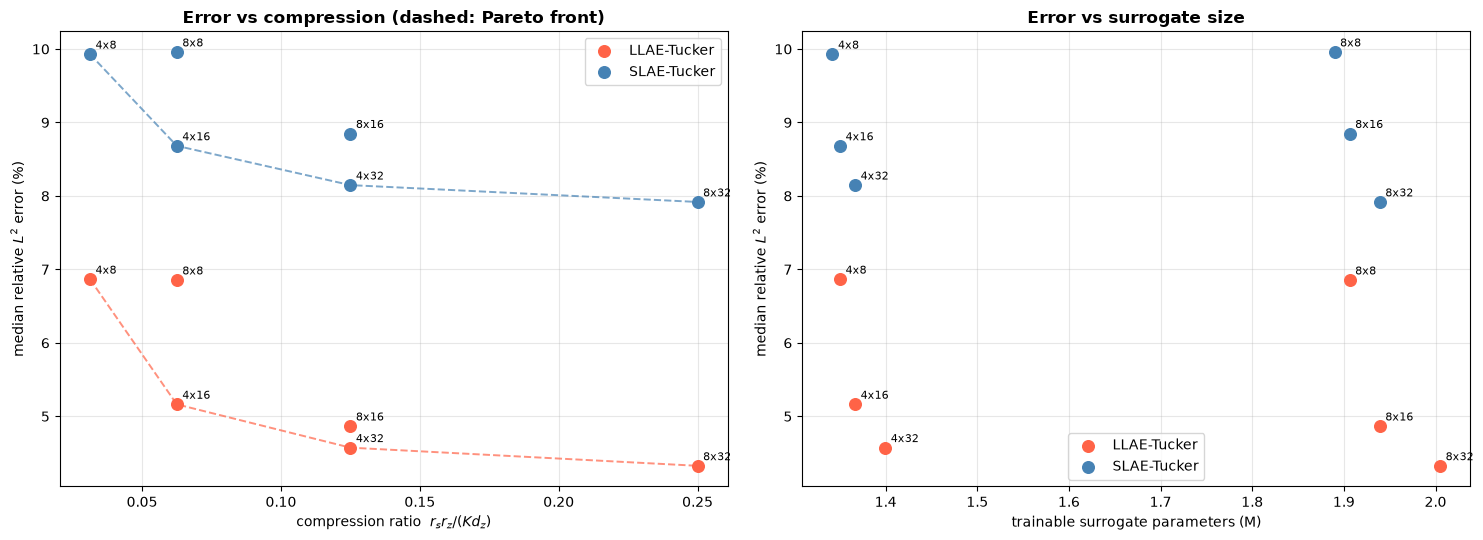

In [11]:
def _pareto(xs, ys):
    """Pareto front (increasing compression ratio, decreasing error)."""
    fx, fy, best = [], [], np.inf
    for i in np.argsort(xs):
        if ys[i] < best:
            best = ys[i]; fx.append(xs[i]); fy.append(ys[i])
    return fx, fy


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

for cls in CLSS:
    xs, ys, ps, lbl = [], [], [], []
    for n in PLOTTED:
        d = meta[n]
        if d['cls'] != cls:
            continue
        xs.append(d['ratio']); ys.append(np.median(results[n]['l2rel']))
        ps.append(d['n_surr'] / 1e6); lbl.append(f"{d['r_s']}x{d['r_z']}")
    xs, ys, ps = np.array(xs), np.array(ys), np.array(ps)

    # several (r_s, r_z) share the same ratio -> scatter + Pareto front, not a line plot
    ax1.scatter(xs, ys, color=PALETTE[cls], s=70, label=FAMILY[cls], zorder=3)
    fx, fy = _pareto(xs, ys)
    ax1.plot(fx, fy, '--', color=PALETTE[cls], alpha=0.7, lw=1.4, zorder=2)
    for x, y, t in zip(xs, ys, lbl):
        ax1.annotate(t, (x, y), fontsize=8, xytext=(4, 4), textcoords='offset points')

    ax2.scatter(ps, ys, color=PALETTE[cls], s=70, label=FAMILY[cls], zorder=3)
    for x, y, t in zip(ps, ys, lbl):
        ax2.annotate(t, (x, y), fontsize=8, xytext=(4, 4), textcoords='offset points')

ax1.set_xlabel(r'compression ratio  $r_s r_z / (K d_z)$')
ax1.set_ylabel(r'median relative $L^2$ error (%)')
ax1.set_title('Error vs compression (dashed: Pareto front)', fontweight='bold')
ax1.grid(alpha=0.3); ax1.legend()

ax2.set_xlabel('trainable surrogate parameters (M)')
ax2.set_ylabel(r'median relative $L^2$ error (%)')
ax2.set_title('Error vs surrogate size', fontweight='bold')
ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout()
plt.show()

## 9. Per-checkpoint error distributions

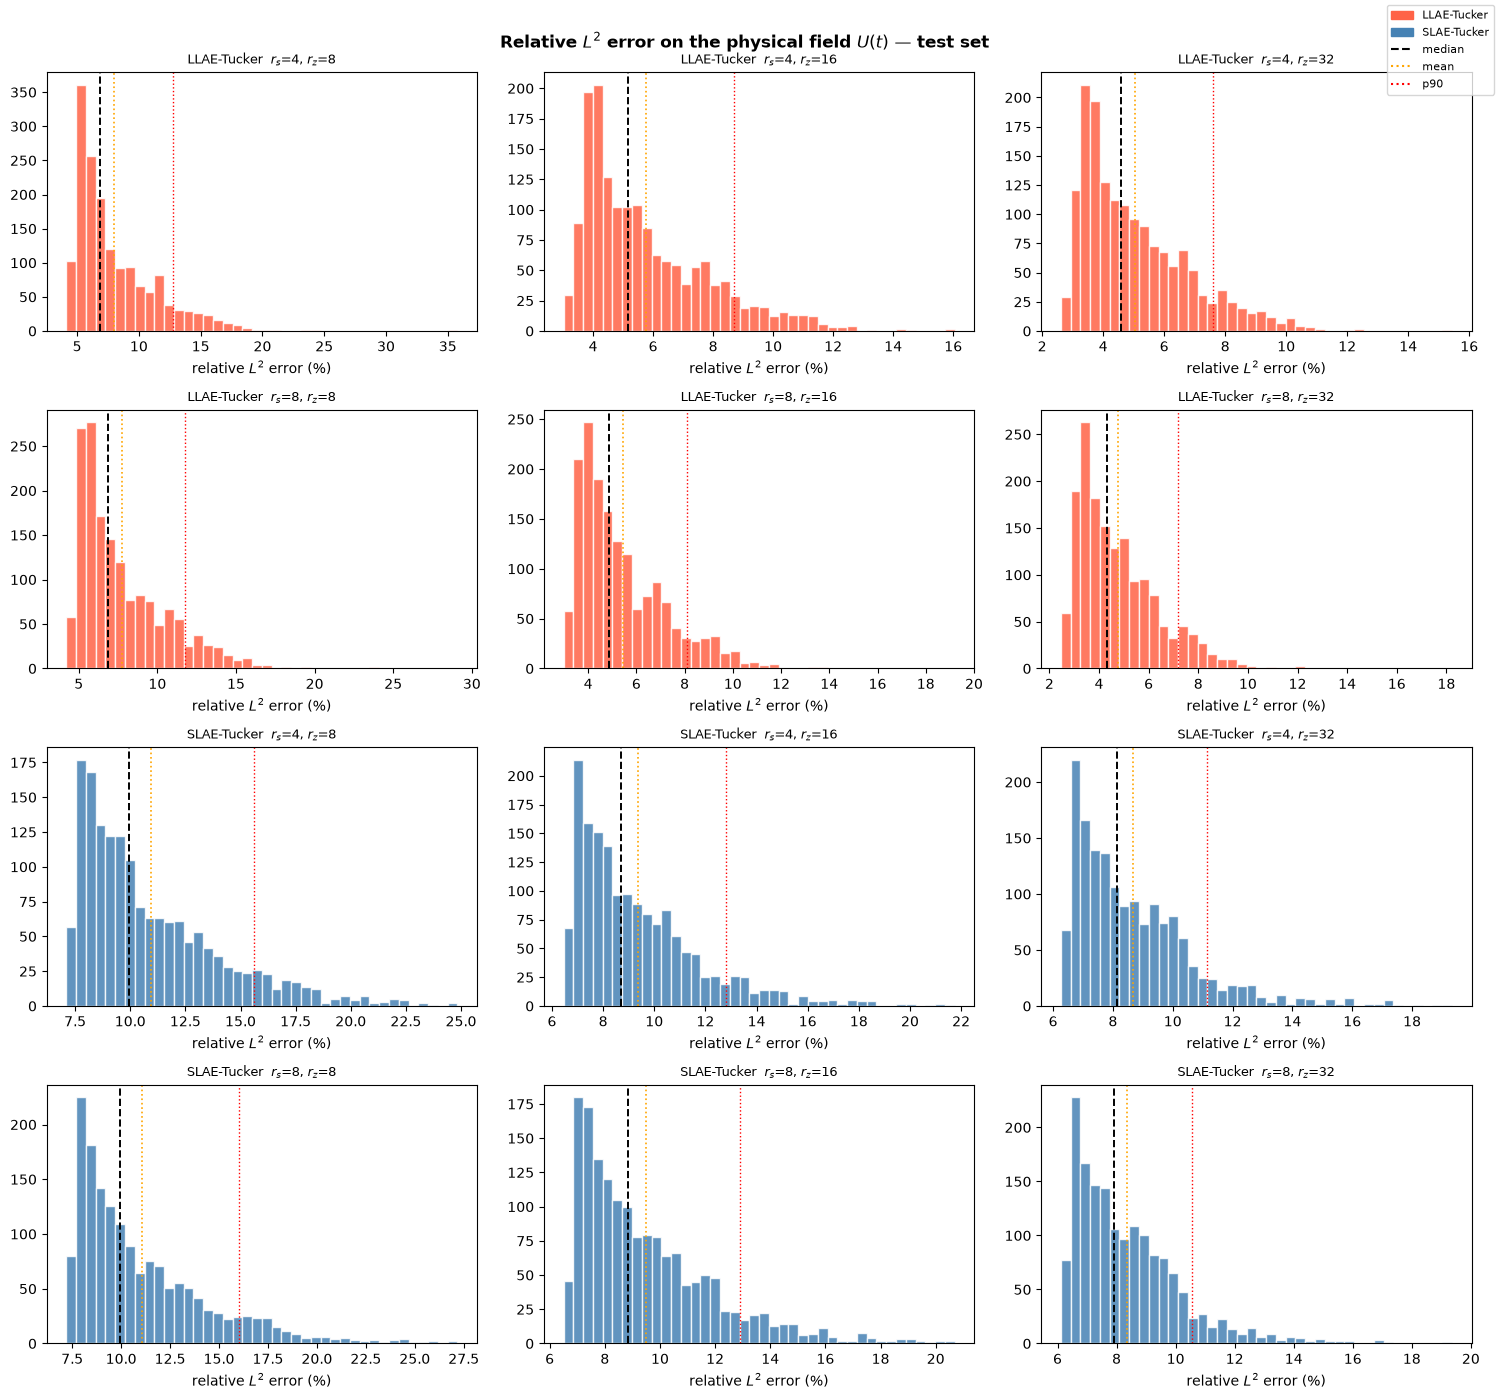

In [12]:
ncols = 3
nrows = int(np.ceil(len(PLOTTED) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, n in zip(axes, PLOTTED):
    d, l2 = meta[n], results[n]['l2rel']
    ax.hist(l2, bins=40, color=PALETTE[d['cls']], edgecolor='white', alpha=0.85)
    ax.axvline(np.median(l2),         color='black',  linestyle='--', linewidth=1.4)
    ax.axvline(np.mean(l2),           color='orange', linestyle=':',  linewidth=1.2)
    ax.axvline(np.percentile(l2, 90), color='red',    linestyle=':',  linewidth=1.0)
    ax.set_title(f"{FAMILY[d['cls']]}  $r_s$={d['r_s']}, $r_z$={d['r_z']}", fontsize=9)
    ax.set_xlabel(r'relative $L^2$ error (%)')
for ax in axes[len(PLOTTED):]:
    ax.axis('off')

handles = [Patch(color=PALETTE[c], label=FAMILY[c]) for c in CLSS]
handles += [plt.Line2D([], [], color='black', ls='--', label='median'),
            plt.Line2D([], [], color='orange', ls=':', label='mean'),
            plt.Line2D([], [], color='red', ls=':', label='p90')]
fig.legend(handles=handles, loc='upper right', fontsize=8)
fig.suptitle(r'Relative $L^2$ error on the physical field $U(t)$ — test set', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Inference latency

latency:   0%|          | 0/12 [00:00<?, ?it/s]

latency:   8%|▊         | 1/12 [00:01<00:12,  1.17s/it]

latency:  17%|█▋        | 2/12 [00:02<00:11,  1.17s/it]

latency:  25%|██▌       | 3/12 [00:03<00:10,  1.17s/it]

latency:  33%|███▎      | 4/12 [00:04<00:09,  1.18s/it]

...

latency:  75%|███████▌  | 9/12 [00:08<00:02,  1.37it/s]

latency:  83%|████████▎ | 10/12 [00:09<00:01,  1.48it/s]

latency:  92%|█████████▏| 11/12 [00:09<00:00,  1.57it/s]

latency: 100%|██████████| 12/12 [00:10<00:00,  1.64it/s]

latency: 100%|██████████| 12/12 [00:10<00:00,  1.16it/s]

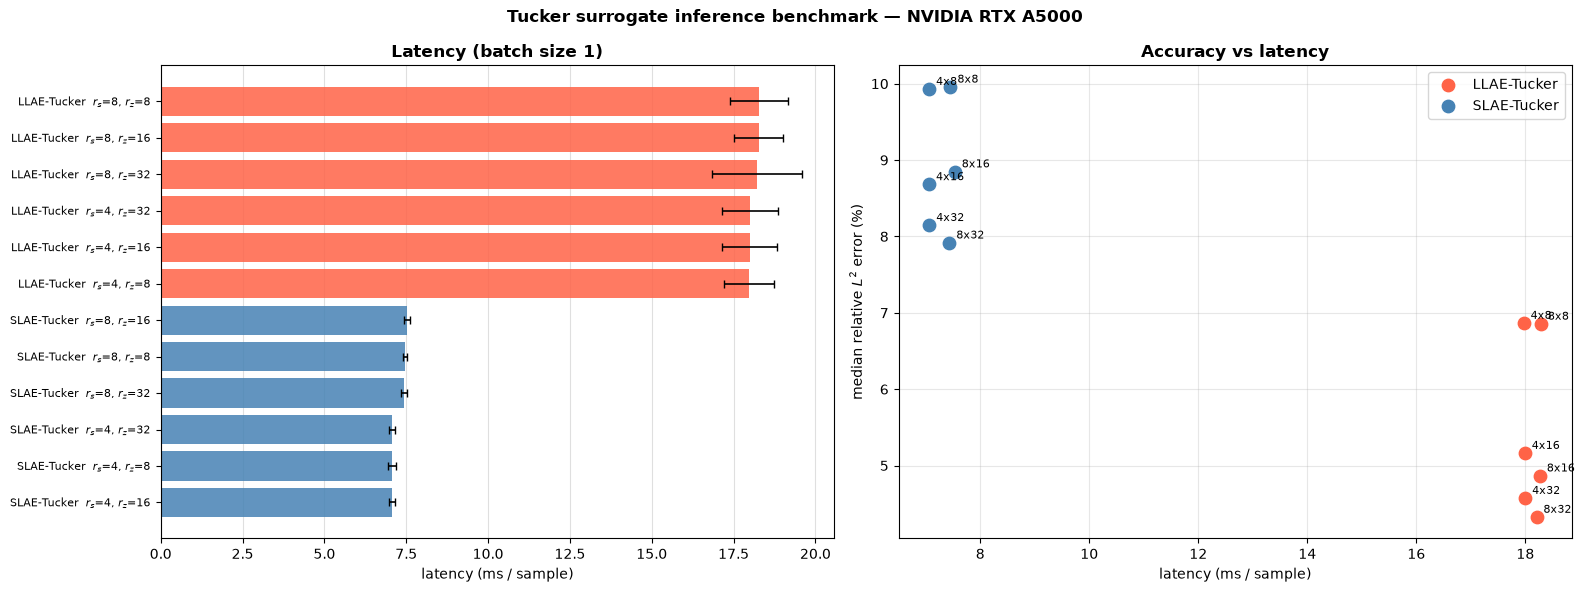

In [13]:
N_WARMUP, N_RUNS = 10, 50


def _time_gpu(fn, n_warmup, n_runs):
    for _ in range(n_warmup):
        fn()
    torch.cuda.synchronize()
    s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    ms = []
    for _ in range(n_runs):
        s.record(); fn(); e.record(); torch.cuda.synchronize()
        ms.append(s.elapsed_time(e))
    return np.array(ms)


bench = {}
for n in tqdm(PLOTTED, desc='latency'):
    pipe = InferencePipeline.from_checkpoint(meta[n]['path'], device=device)
    tm = pipe.ckpt['theta_mean'].to(device).float(); ts = pipe.ckpt['theta_std'].to(device).float()
    tn = (torch.from_numpy(theta_np[test_idx[:1]]).to(device) - tm) / ts

    def run():
        with torch.no_grad():
            pipe.model.generate(tn)

    if device == 'cuda':
        ms = _time_gpu(run, N_WARMUP, N_RUNS)
    else:
        import time
        ms = []
        for i in range(N_WARMUP + N_RUNS):
            t0 = time.perf_counter(); run()
            if i >= N_WARMUP: ms.append((time.perf_counter() - t0) * 1e3)
        ms = np.array(ms)
    bench[n] = dict(med=float(np.median(ms)), std=float(np.std(ms)))
    pipe.model.cpu(); del pipe
    if device == 'cuda': torch.cuda.empty_cache()

def _label(n):
    d = meta[n]
    return f"{FAMILY[d['cls']]}  $r_s$={d['r_s']}, $r_z$={d['r_z']}"


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: per-checkpoint latency, sorted
order = sorted(PLOTTED, key=lambda n: bench[n]['med'])
y     = np.arange(len(order))
lats  = [bench[n]['med'] for n in order]
stds  = [bench[n]['std'] for n in order]
cols  = [PALETTE[meta[n]['cls']] for n in order]

ax1.barh(y, lats, color=cols, alpha=0.85, zorder=2)
ax1.errorbar(lats, y, xerr=stds, fmt='none', color='black', capsize=3, linewidth=1.2, zorder=3)
ax1.set_yticks(y); ax1.set_yticklabels([_label(n) for n in order], fontsize=8)
ax1.set_xlabel('latency (ms / sample)')
ax1.set_title('Latency (batch size 1)', fontweight='bold')
ax1.grid(axis='x', alpha=0.4, zorder=0)

# Right: accuracy vs latency
for cls in CLSS:
    sel = [n for n in PLOTTED if meta[n]['cls'] == cls]
    ax2.scatter([bench[n]['med'] for n in sel],
                [np.median(results[n]['l2rel']) for n in sel],
                color=PALETTE[cls], s=80, label=FAMILY[cls], zorder=3)
    for n in sel:
        ax2.annotate(f"{meta[n]['r_s']}x{meta[n]['r_z']}",
                     (bench[n]['med'], np.median(results[n]['l2rel'])),
                     fontsize=8, xytext=(5, 3), textcoords='offset points')
ax2.set_xlabel('latency (ms / sample)')
ax2.set_ylabel(r'median relative $L^2$ error (%)')
ax2.set_title('Accuracy vs latency', fontweight='bold')
ax2.grid(alpha=0.3); ax2.legend()

fig.suptitle(f"Tucker surrogate inference benchmark — "
             f"{torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'}", fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Summary table

In [14]:
hdr = (f"{'variant':<12} {'r_s':>4} {'r_z':>4} {'ratio':>7} {'params':>10} "
       f"{'median':>8} {'mean':>7} {'p90':>7} {'trunc':>7} {'reg':>7} {'lat_ms':>7}")
print(hdr); print('-' * len(hdr))
for n in PLOTTED:
    d, r = meta[n], results[n]
    print(f"{FAMILY[d['cls']]:<12} {d['r_s']:>4} {d['r_z']:>4} {d['ratio']:>7.3f} {d['n_surr']:>10,} "
          f"{np.median(r['l2rel']):>8.2f} {np.mean(r['l2rel']):>7.2f} "
          f"{np.percentile(r['l2rel'], 90):>7.2f} {np.median(r['trunc']):>7.2f} "
          f"{np.median(r['reg']):>7.2f} {bench[n]['med']:>7.2f}")

best = min(PLOTTED, key=lambda n: np.median(results[n]['l2rel']))
b    = meta[best]
print(f'\nn = {len(test_idx)} test simulations, errors in %. '
      f"Best: {FAMILY[b['cls']]} r_s={b['r_s']}, r_z={b['r_z']} "
      f"({np.median(results[best]['l2rel']):.2f}% median, ratio {b['ratio']:.3f}).")

variant       r_s  r_z   ratio     params   median    mean     p90   trunc     reg  lat_ms
------------------------------------------------------------------------------------------
LLAE-Tucker     4    8   0.031  1,350,212     6.87    8.02   12.73   81.03    3.80   17.97
LLAE-Tucker     4   16   0.062  1,366,660     5.16    5.77    8.70   61.59    3.83   17.99
LLAE-Tucker     4   32   0.125  1,399,556     4.57    5.04    7.61   40.34    5.67   18.00
LLAE-Tucker     8    8   0.062  1,906,312     6.85    7.78   11.75   81.21    4.99   18.29
LLAE-Tucker     8   16   0.125  1,939,208     4.87    5.43    8.11   61.86    4.38   18.27
LLAE-Tucker     8   32   0.250  2,005,000     4.33    4.75    7.16   36.98    7.25   18.20
SLAE-Tucker     4    8   0.031  1,341,988     9.93   10.92   15.61   80.63    5.70    7.06
SLAE-Tucker     4   16   0.062  1,350,212     8.68    9.36   12.79   69.59    5.18    7.06
SLAE-Tucker     4   32   0.125  1,366,660     8.15    8.68   11.14   50.82    6.58    7.07